In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import accuracy_score, recall_score, f1_score

MISLABELS_CSV = Path("/home/student/lisa_ma/results/glare/26-09-26_07:42_ep-8_single-gpu/mislabels_list_20260926_074211.csv")
RC_XLSX       = Path("/home/student/lisa_ma/evaluation/gt_mislabels_complete_LO.xlsx")
MAX_SCORE     = 8

scores_df = pd.read_csv(MISLABELS_CSV, dtype=str, keep_default_na=False)
scores_df["glare_score"] = pd.to_numeric(scores_df["glare score"], errors="coerce")
scores_df = scores_df.dropna(subset=["glare_score"]).reset_index(drop=True)

In [2]:
# To get the mislabeled / clean label
df_rc     = pd.read_excel(RC_XLSX)                           # kein sheet_name nötig
positives = set(df_rc["sample_id"].astype(str))             # sample_id statt id, kein in_training_data Filter
scores_df["mislabeled"] = scores_df["id"].apply(lambda x: 1 if x in positives else 0)

/tmp/ipykernel_3723556/2000013823.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, loc="lower right")


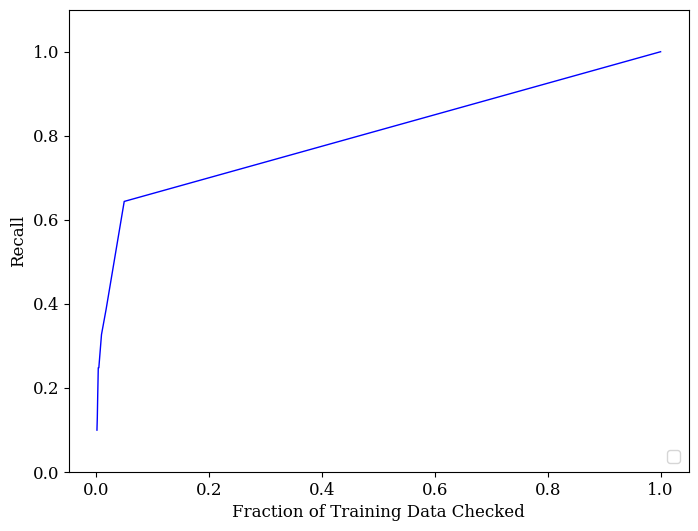

In [3]:
metric = "Recall"

metrics = []

for threshold in range(MAX_SCORE + 1):
    fraction = (scores_df["glare_score"] <= threshold).sum() / len(scores_df)

    y_true = scores_df["mislabeled"]
    y_pred = scores_df["glare_score"].apply(lambda s: 1 if s <= threshold else 0)

    accuracy = accuracy_score(y_true, y_pred)
    recall   = recall_score(y_true, y_pred, zero_division=0)
    f1       = f1_score(y_true, y_pred, zero_division=0)

    metrics.append({
        "Fraction": fraction,
        "Accuracy": accuracy,
        "Recall":   recall,
        "F1":       f1
    })

metrics_df = pd.DataFrame(metrics)

metrics_melted = metrics_df.melt(
    id_vars=["Fraction"],
    value_vars=["Accuracy", "Recall", "F1"],
    var_name="Metric",
    value_name="Value"
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12
})

df_filtered = metrics_melted[metrics_melted["Metric"] == metric]

plt.figure(figsize=(8, 6))

plt.ylim(0.0, 1.1)

plt.plot(df_filtered["Fraction"], df_filtered["Value"], color="b", linewidth=1)

plt.xlabel("Fraction of Training Data Checked")
plt.ylabel(metric)

plt.legend(frameon=True, loc="lower right")

plt.show()

In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score

# ── Dataset summary ───────────────────────────────────────────────────────────
n_total     = len(scores_df)
n_mislabels = scores_df["mislabeled"].sum()
base_rate   = scores_df["mislabeled"].mean()

# ── Per-threshold metrics ─────────────────────────────────────────────────────
y_true   = scores_df["mislabeled"].values
inverted = MAX_SCORE - scores_df["glare_score"].values  # high = suspicious

auroc = roc_auc_score(y_true, inverted)
ap    = average_precision_score(y_true, inverted)

rows = []
for threshold in range(MAX_SCORE + 1):
    y_pred    = (scores_df["glare_score"] <= threshold).astype(int).values
    fraction  = y_pred.sum() / n_total
    recall    = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    rows.append({"threshold": threshold, "fraction": fraction,
                 "recall": recall, "precision": precision, "f1": f1})

detail_df = pd.DataFrame(rows)
best      = detail_df.loc[detail_df["f1"].idxmax()]

# ── Print ─────────────────────────────────────────────────────────────────────
print("=" * 52)
print("  GLARE Run Summary — VerSe Sep 26, 2026 (single-gpu)")
print("=" * 52)
print(f"  Training samples:              {n_total:,}")
print(f"  Confirmed mislabels:           {n_mislabels}")
print(f"  Base mislabel rate:            {base_rate:.2%}")
print(f"  Training epochs:               {MAX_SCORE}")
print(f"  GLARE score range:             0 – {MAX_SCORE}")
print()
print("  Detection Performance")
print("  " + "-" * 38)
print(f"  AUROC:                         {auroc:.4f}")
print(f"  Average Precision:             {ap:.4f}")
print(f"  Best F1:                       {best.f1:.4f}  (score ≤ {int(best.threshold)})")
print(f"    Recall at best F1:           {best.recall:.2%}")
print(f"    Precision at best F1:        {best.precision:.2%}")
print(f"    Fraction checked:            {best.fraction:.2%}")
print("=" * 52)
print()
print("  Full threshold table:")
print(detail_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


  GLARE Run Summary — VerSe Sep 26, 2026 (single-gpu)
  Training samples:              19,266
  Confirmed mislabels:           101
  Base mislabel rate:            0.52%
  Training epochs:               8
  GLARE score range:             0 – 8

  Detection Performance
  --------------------------------------
  AUROC:                         0.8044
  Average Precision:             0.1578
  Best F1:                       0.3049  (score ≤ 3)
    Recall at best F1:           24.75%
    Precision at best F1:        39.68%
    Fraction checked:            0.33%

  Full threshold table:
 threshold  fraction  recall  precision     f1
         0    0.0009  0.0990     0.5556 0.1681
         1    0.0016  0.1287     0.4333 0.1985
         2    0.0022  0.1782     0.4186 0.2500
         3    0.0033  0.2475     0.3968 0.3049
         4    0.0043  0.2475     0.3049 0.2732
         5    0.0090  0.3267     0.1908 0.2409
         6    0.0171  0.3861     0.1185 0.1814
         7    0.0493  0.6436     0.06

In [5]:
# ── Rank-based summary table (Luca-style: fraction checked → Recall / Precision / F1) ──
from IPython.display import display

sorted_df = scores_df.sort_values("glare_score").reset_index(drop=True)
n         = len(sorted_df)
n_pos     = int(sorted_df["mislabeled"].sum())

fracs = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.00]
rows  = []
for frac in fracs:
    k         = max(1, int(frac * n))
    tp        = int(sorted_df.iloc[:k]["mislabeled"].sum())
    recall    = tp / n_pos
    precision = tp / k
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    rows.append({
        "Fraction checked": f"{frac*100:.1f}%",
        "Samples checked":  k,
        "TP":               tp,
        "Recall":           f"{recall*100:.1f}%",
        "Precision":        f"{precision*100:.1f}%",
        "F1":               f"{f1*100:.1f}%",
    })

tbl = pd.DataFrame(rows)

print(f"AUROC: {auroc:.4f}   |   Average Precision: {ap:.4f}\n")
display(
    tbl.style
    .set_caption("Rank-based Recall / Precision / F1 by fraction of training data checked (Sep-26 run, ep-8)")
    .hide(axis="index")
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("margin-bottom", "6px")]},
    ])
)

AUROC: 0.8044   |   Average Precision: 0.1578



Fraction checked,Samples checked,TP,Recall,Precision,F1
0.1%,19,10,9.9%,52.6%,16.7%
0.5%,96,27,26.7%,28.1%,27.4%
1.0%,192,35,34.7%,18.2%,23.9%
2.0%,385,43,42.6%,11.2%,17.7%
5.0%,963,65,64.4%,6.7%,12.2%
10.0%,1926,66,65.3%,3.4%,6.5%
20.0%,3853,70,69.3%,1.8%,3.5%
50.0%,9633,81,80.2%,0.8%,1.7%
100.0%,19266,101,100.0%,0.5%,1.0%


In [6]:
# ── ep-8 run (Sep 26 2026, single-gpu): load data ────────────────────────────
MISLABELS_CSV_8 = Path("/home/student/lisa_ma/results/glare/26-09-26_07:42_ep-8_single-gpu/mislabels_list_20260926_074211.csv")
MAX_SCORE_8 = 8

scores_df_8 = pd.read_csv(MISLABELS_CSV_8, dtype=str, keep_default_na=False)
scores_df_8["glare_score"] = pd.to_numeric(scores_df_8["glare score"], errors="coerce")
scores_df_8 = scores_df_8.dropna(subset=["glare_score"]).reset_index(drop=True)
scores_df_8["mislabeled"] = scores_df_8["id"].apply(lambda x: 1 if x in positives else 0)

score_vals_8      = list(range(MAX_SCORE_8 + 1))
clean_counts_8    = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 0)).sum()) for s in score_vals_8]
mislabel_counts_8 = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 1)).sum()) for s in score_vals_8]

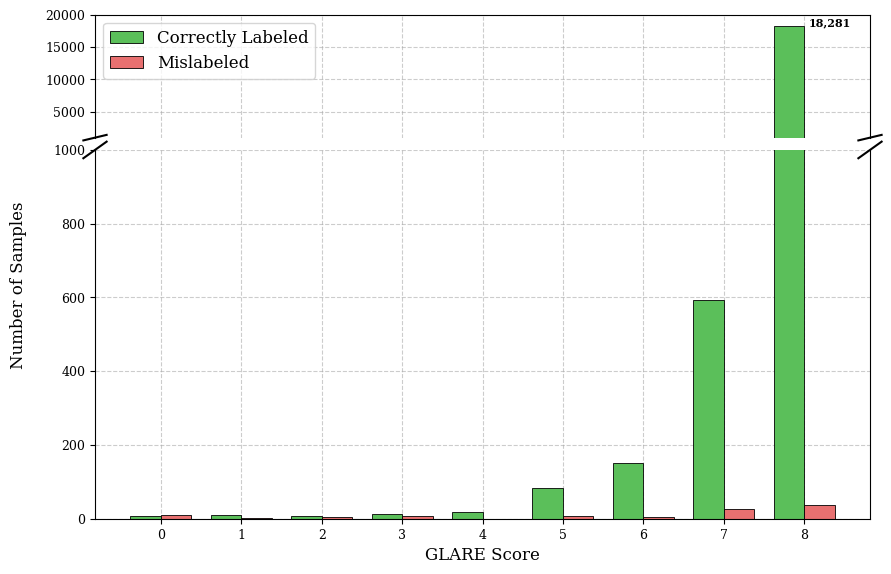

In [7]:
# ── Combined histogram (ep-8 new, lower_ylim=1000) ───────────────────────────
lower_ylim_8 = 1000
top_ylim_8   = min(20000, int(np.ceil(max(clean_counts_8) * 1.15)))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals_8))
bar_w = 0.38

for ax in (ax_top, ax_bottom):
    ax.bar(x - bar_w/2, clean_counts_8,    width=bar_w, color="#5BBF5A", edgecolor="black", linewidth=0.6, label="Correctly Labeled")
    ax.bar(x + bar_w/2, mislabel_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_ylim(lower_ylim_8, top_ylim_8)
ax_bottom.set_ylim(0, lower_ylim_8)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

for i, c in enumerate(clean_counts_8):
    if c > lower_ylim_8:
        bar_right = x[i] - bar_w/2 + bar_w/2 + 0.05
        y_pos     = lower_ylim_8 + (top_ylim_8 - lower_ylim_8) * 0.98
        ax_top.text(bar_right, y_pos, f"{c:,}", ha="left", va="top", fontsize=8, fontweight="bold")

ax_bottom.set_xlabel("GLARE Score", fontsize=12)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals_8, fontsize=10)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper left")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.savefig("/home/student/lisa_ma/figures/histogram_all_ep8_new.jpg", dpi=300, bbox_inches="tight")
plt.show()

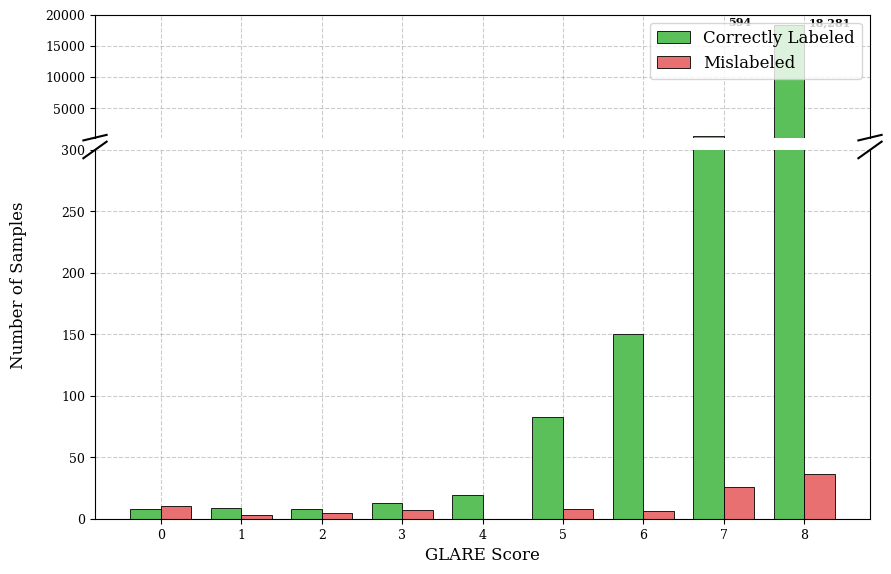

In [8]:
# ── Combined histogram (ep-8 new, lower_ylim=300) ────────────────────────────
lower_ylim_8b = 300
top_ylim_8b   = min(20000, int(np.ceil(max(clean_counts_8) * 1.15)))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals_8))
bar_w = 0.38

for ax in (ax_top, ax_bottom):
    ax.bar(x - bar_w/2, clean_counts_8,    width=bar_w, color="#5BBF5A", edgecolor="black", linewidth=0.6, label="Correctly Labeled")
    ax.bar(x + bar_w/2, mislabel_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_ylim(lower_ylim_8b, top_ylim_8b)
ax_bottom.set_ylim(0, lower_ylim_8b)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

for i, c in enumerate(clean_counts_8):
    if c > lower_ylim_8b:
        bar_right = x[i] - bar_w/2 + bar_w/2 + 0.05
        y_pos     = lower_ylim_8b + (top_ylim_8b - lower_ylim_8b) * 0.98
        ax_top.text(bar_right, y_pos, f"{c:,}", ha="left", va="top", fontsize=8, fontweight="bold")

ax_bottom.set_xlabel("GLARE Score", fontsize=12)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals_8, fontsize=10)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper right")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.savefig("/home/student/lisa_ma/figures/histogram_all_ep8_zoom_new.jpg", dpi=300, bbox_inches="tight")
plt.show()

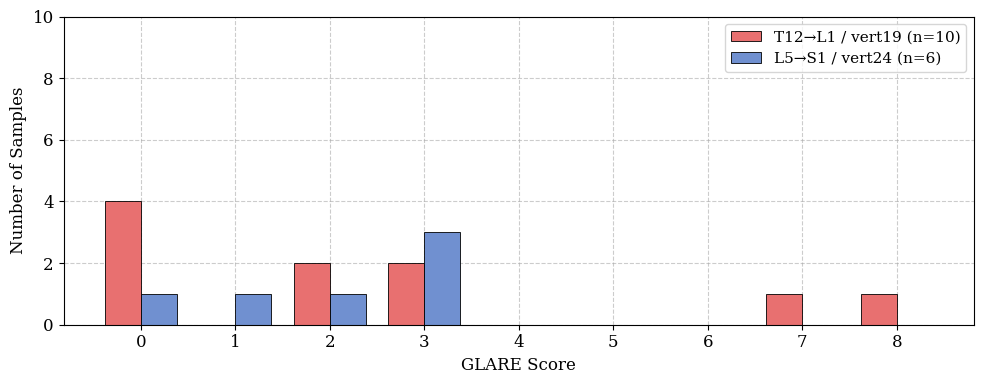

In [9]:
# ── Histogram: T12-missing ep-8 new — T12→L1 (vert19) vs L5→S1 (vert24) ──────
v19_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 19)]["sample_id"].astype(str))
v24_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 24)]["sample_id"].astype(str))

v19_df_8 = scores_df_8[scores_df_8["id"].isin(v19_ids)]
v24_df_8 = scores_df_8[scores_df_8["id"].isin(v24_ids)]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
v19_counts_8 = [int((v19_df_8["glare_score"] == s).sum()) for s in score_vals_8]
v24_counts_8 = [int((v24_df_8["glare_score"] == s).sum()) for s in score_vals_8]

x     = np.arange(len(score_vals_8))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - bar_w/2, v19_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label=f"T12→L1 / vert19 (n={len(v19_df_8)})")
ax.bar(x + bar_w/2, v24_counts_8, width=bar_w, color="#7090D0", edgecolor="black", linewidth=0.6, label=f"L5→S1 / vert24 (n={len(v24_df_8)})")
ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.set_ylim(0, 10)
ax.set_yticks(range(0, 11, 2))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/histogram_T12missing_ep8_new.jpg", dpi=300, bbox_inches="tight")
plt.show()

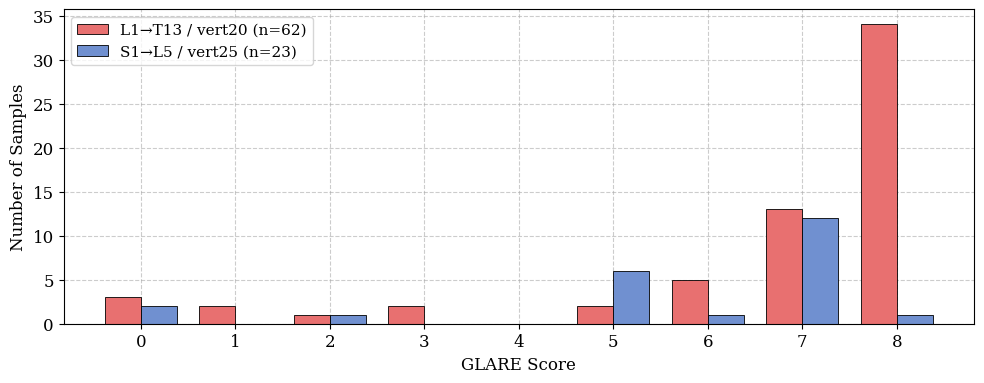

In [10]:
# ── Histogram: T13-extra ep-8 new — L1→T13 (vert20) vs S1→L5 (vert25) ────────
v20_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 20)]["sample_id"].astype(str))
v25_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 25)]["sample_id"].astype(str))

v20_df_8 = scores_df_8[scores_df_8["id"].isin(v20_ids)]
v25_df_8 = scores_df_8[scores_df_8["id"].isin(v25_ids)]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
v20_counts_8 = [int((v20_df_8["glare_score"] == s).sum()) for s in score_vals_8]
v25_counts_8 = [int((v25_df_8["glare_score"] == s).sum()) for s in score_vals_8]

x     = np.arange(len(score_vals_8))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - bar_w/2, v20_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label=f"L1→T13 / vert20 (n={len(v20_df_8)})")
ax.bar(x + bar_w/2, v25_counts_8, width=bar_w, color="#7090D0", edgecolor="black", linewidth=0.6, label=f"S1→L5 / vert25 (n={len(v25_df_8)})")
ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/histogram_T13extra_ep8_new.jpg", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_3723556/291055426.py:17: RuntimeWarning: invalid value encountered in divide
  f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)
/tmp/ipykernel_3723556/291055426.py:17: RuntimeWarning: invalid value encountered in divide
  f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)


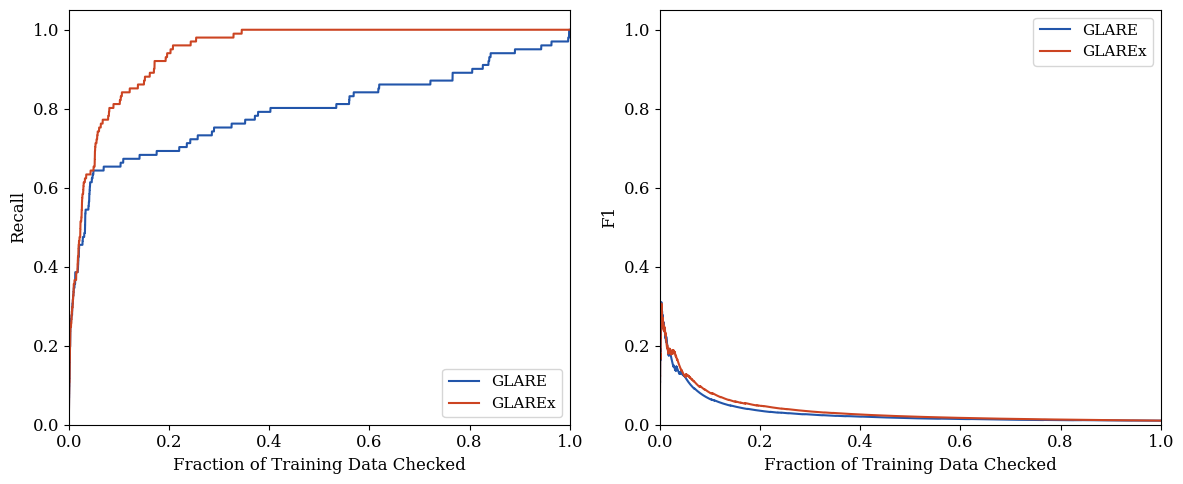

Fraction checked → Recall / F1 (GLARE | GLAREx)
  1%  GLARE  R=34.7%  F1=0.239  |  GLAREx  R=35.6%  F1=0.246
  5%  GLARE  R=64.4%  F1=0.122  |  GLAREx  R=65.3%  F1=0.124
  10%  GLARE  R=65.3%  F1=0.065  |  GLAREx  R=81.2%  F1=0.081
  20%  GLARE  R=69.3%  F1=0.035  |  GLAREx  R=94.1%  F1=0.048
  50%  GLARE  R=80.2%  F1=0.017  |  GLAREx  R=100.0%  F1=0.021


In [11]:
# ── Rank-based Recall / F1 Curves — GLARE vs GLAREx (ep-8 new) ───────────────
scores_df_8["glarex_score"] = pd.to_numeric(scores_df_8.get("glarex score", pd.Series(dtype=float)), errors="coerce")

n_total_8     = len(scores_df_8)
n_mislabels_8 = int(scores_df_8["mislabeled"].sum())

def all_curves(df, score_col):
    sorted_df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=True).reset_index(drop=True)
    n         = len(sorted_df)
    n_pos     = int(sorted_df["mislabeled"].sum())
    fracs     = np.arange(1, n + 1) / n
    cum_found = sorted_df["mislabeled"].cumsum().values
    k         = np.arange(1, n + 1)
    recall    = cum_found / n_pos
    precision = cum_found / k
    denom     = precision + recall
    f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)
    return fracs, recall, f1

fracs_g,  rec_g,  f1_g  = all_curves(scores_df_8, "glare_score")
fracs_gx, rec_gx, f1_gx = all_curves(scores_df_8, "glarex_score")

plt.rcParams.update({"font.family": "serif", "font.size": 12})

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5))

ax_l.plot(fracs_g,  rec_g,  color="#2255AA", linewidth=1.5, label="GLARE")
ax_l.plot(fracs_gx, rec_gx, color="#CC4422", linewidth=1.5, label="GLAREx")
ax_l.set_xlabel("Fraction of Training Data Checked", fontsize=12)
ax_l.set_ylabel("Recall", fontsize=12)
ax_l.set_xlim(0, 1)
ax_l.set_ylim(0, 1.05)
ax_l.legend(fontsize=11, frameon=True, loc="lower right")
ax_l.set_facecolor("white")
ax_l.grid(False)

ax_r.plot(fracs_g,  f1_g,  color="#2255AA", linewidth=1.5, label="GLARE")
ax_r.plot(fracs_gx, f1_gx, color="#CC4422", linewidth=1.5, label="GLAREx")
ax_r.set_xlabel("Fraction of Training Data Checked", fontsize=12)
ax_r.set_ylabel("F1", fontsize=12)
ax_r.set_xlim(0, 1)
ax_r.set_ylim(0, 1.05)
ax_r.legend(fontsize=11, frameon=True, loc="upper right")
ax_r.set_facecolor("white")
ax_r.grid(False)

plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/recall_f1_curve_ep8_new.jpg", dpi=300, bbox_inches="tight")
plt.show()

print("Fraction checked → Recall / F1 (GLARE | GLAREx)")
for frac in [0.01, 0.05, 0.10, 0.20, 0.50]:
    i_g  = min(int(np.searchsorted(fracs_g,  frac, side="right")) - 1, len(fracs_g)  - 1)
    i_gx = min(int(np.searchsorted(fracs_gx, frac, side="right")) - 1, len(fracs_gx) - 1)
    print(f"  {frac:.0%}  GLARE  R={rec_g[i_g]:.1%}  F1={f1_g[i_g]:.3f}"
          f"  |  GLAREx  R={rec_gx[i_gx]:.1%}  F1={f1_gx[i_gx]:.3f}")


In [12]:
# ── Rank-based GLARE vs GLAREx table (Table 6.2 style, LO-corrected run) ─────
from sklearn.metrics import roc_auc_score
from IPython.display import display

sorted_g  = scores_df_8.sort_values("glare_score").reset_index(drop=True)
sorted_gx = scores_df_8.dropna(subset=["glarex_score"]).sort_values("glarex_score").reset_index(drop=True)

n_g   = len(sorted_g)
n_gx  = len(sorted_gx)
n_pos = int(sorted_g["mislabeled"].sum())

auroc_g  = roc_auc_score(sorted_g["mislabeled"].values,  MAX_SCORE_8 - sorted_g["glare_score"].values)
auroc_gx = roc_auc_score(sorted_gx["mislabeled"].values, MAX_SCORE_8 - sorted_gx["glarex_score"].values)
print(f"AUROC — GLARE: {auroc_g:.4f}   GLAREx: {auroc_gx:.4f}\n")

fracs = [0.001, 0.002, 0.005, 0.010, 0.020, 0.050, 0.100, 0.200]
rows  = []
for frac in fracs:
    k = max(1, int(frac * n_g))
    tp_g  = int(sorted_g.iloc[:k]["mislabeled"].sum())
    tp_gx = int(sorted_gx.iloc[:k]["mislabeled"].sum())
    rg  = tp_g  / n_pos;  pg  = tp_g  / k
    rgx = tp_gx / n_pos;  pgx = tp_gx / k
    fg  = 2*pg *rg /(pg +rg ) if pg +rg  > 0 else 0
    fgx = 2*pgx*rgx/(pgx+rgx) if pgx+rgx > 0 else 0
    rows.append({
        "Frac. (%)":          f"{frac*100:.1f}",
        "Flagged":            k,
        "G Rec. (%)":         f"{rg *100:.1f}",
        "G Prec. (%)":        f"{pg *100:.1f}",
        "G F1 (%)":           f"{fg *100:.1f}",
        "GX Rec. (%)":        f"{rgx*100:.1f}",
        "GX Prec. (%)":       f"{pgx*100:.1f}",
        "GX F1 (%)":          f"{fgx*100:.1f}",
        "Δ TP":          f"{tp_gx - tp_g:+d}",
    })

tbl = pd.DataFrame(rows)
display(
    tbl.style
    .set_caption("Rank-based detection performance: GLARE vs GLAREx (LO-corrected run, 102 GT mislabels)")
    .hide(axis="index")
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("margin-bottom", "6px")]},
    ])
)
print(tbl.to_string(index=False))

AUROC — GLARE: 0.8044   GLAREx: 0.9492



Frac. (%),Flagged,G Rec. (%),G Prec. (%),G F1 (%),GX Rec. (%),GX Prec. (%),GX F1 (%),Δ TP
0.1,19,9.9,52.6,16.7,9.9,52.6,16.7,+0
0.2,38,15.8,42.1,23.0,16.8,44.7,24.5,+1
0.5,96,26.7,28.1,27.4,25.7,27.1,26.4,-1
1.0,192,34.7,18.2,23.9,35.6,18.8,24.6,+1
2.0,385,42.6,11.2,17.7,45.5,11.9,18.9,+3
5.0,963,64.4,6.7,12.2,65.3,6.9,12.4,+1
10.0,1926,65.3,3.4,6.5,81.2,4.3,8.1,+16
20.0,3853,69.3,1.8,3.5,94.1,2.5,4.8,+25


Frac. (%)  Flagged G Rec. (%) G Prec. (%) G F1 (%) GX Rec. (%) GX Prec. (%) GX F1 (%) Δ TP
      0.1       19        9.9        52.6     16.7         9.9         52.6      16.7   +0
      0.2       38       15.8        42.1     23.0        16.8         44.7      24.5   +1
      0.5       96       26.7        28.1     27.4        25.7         27.1      26.4   -1
      1.0      192       34.7        18.2     23.9        35.6         18.8      24.6   +1
      2.0      385       42.6        11.2     17.7        45.5         11.9      18.9   +3
      5.0      963       64.4         6.7     12.2        65.3          6.9      12.4   +1
     10.0     1926       65.3         3.4      6.5        81.2          4.3       8.1  +16
     20.0     3853       69.3         1.8      3.5        94.1          2.5       4.8  +25


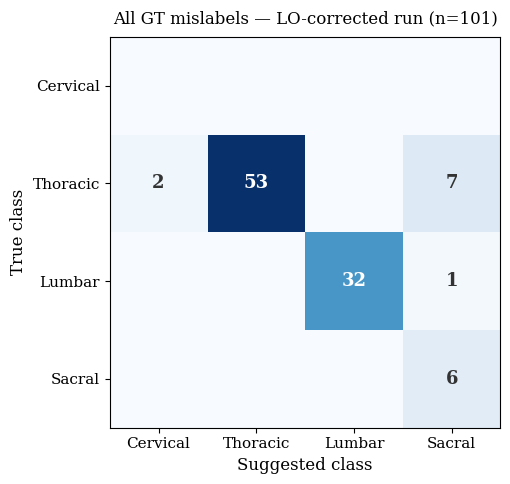

Saved: /home/student/lisa_ma/figures/confusion_matrix_gt_mislabels_LO.jpg

T13-extra score ≥7: n=60
alt_glarex  Cervical  Lumbar  Sacral  Thoracic
true_class                                    
Lumbar             0      13       0         0
Thoracic           2       0       7        38


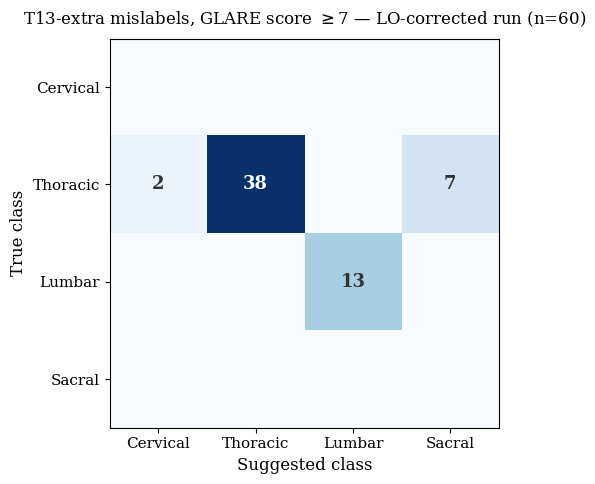

Saved: /home/student/lisa_ma/figures/confusion_matrix_T13_missed_LO.jpg


In [13]:
# ── Confusion matrices: true class vs GLAREx suggested class (LO-corrected run) ─
import matplotlib
matplotlib.rcParams.update({"font.family": "serif", "font.size": 12})

INT_TO_CLASS = {"0": "Cervical", "1": "Thoracic", "2": "Lumbar", "3": "Sacral"}
scores_df_8["alt_glarex"] = scores_df_8["alternative class (glarex)"].map(INT_TO_CLASS)

merged_lo = df_rc.merge(
    scores_df_8[["id", "alt_glarex", "glare_score"]].rename(columns={"id": "sample_id"}),
    on="sample_id", how="left"
)

ORDER = ["Cervical", "Thoracic", "Lumbar", "Sacral"]

def plot_cm(data, title, filename):
    ct = (
        pd.crosstab(data["true_class"], data["alt_glarex"])
        .reindex(index=ORDER, columns=ORDER, fill_value=0)
    )
    vals = ct.values.astype(float)
    vmax = max(vals.max(), 1)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(vals, cmap=plt.cm.Blues, vmin=0, vmax=vmax, aspect="equal")
    for i in range(len(ORDER)):
        for j in range(len(ORDER)):
            v = int(vals[i, j])
            if v == 0:
                continue
            color = "white" if v / vmax > 0.55 else "#333333"
            ax.text(j, i, str(v), ha="center", va="center",
                    fontsize=13, fontweight="bold", color=color)
    ax.set_xticks(range(len(ORDER)))
    ax.set_yticks(range(len(ORDER)))
    ax.set_xticklabels(ORDER, fontsize=11)
    ax.set_yticklabels(ORDER, fontsize=11)
    ax.set_xlabel("Suggested class", fontsize=12)
    ax.set_ylabel("True class", fontsize=12)
    ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")

# Version 1: all GT mislabels (n=102, LO-corrected)
plot_cm(
    merged_lo,
    f"All GT mislabels — LO-corrected run (n={len(merged_lo)})",
    "/home/student/lisa_ma/figures/confusion_matrix_gt_mislabels_LO.jpg"
)

# Version 2: T13-extra only, GLARE score >= 7
t13_missed_lo = merged_lo[
    (merged_lo["anomaly_type"] == "T13_extra") &
    (merged_lo["glare_score"] >= 7)
]
print(f"\nT13-extra score ≥7: n={len(t13_missed_lo)}")
print(pd.crosstab(t13_missed_lo["true_class"], t13_missed_lo["alt_glarex"]))

plot_cm(
    t13_missed_lo,
    f"T13-extra mislabels, GLARE score $\\geq$7 — LO-corrected run (n={len(t13_missed_lo)})",
    "/home/student/lisa_ma/figures/confusion_matrix_T13_missed_LO.jpg"
)